# Case 3: Minimize CVaR with simplified UCITS constraints

## Data load

In [1]:
import numpy as np
import pandas as pd
import cvxpy as cp
import tensorflow as tf

import data_management as dm
from portfolios import Portfolio, Portfolio_Collection
from models import MPOModel
import risk_measures as rm
from utils import (
    mask_greater_than,
    sparsemax,
)

import warnings

warnings.filterwarnings("ignore")
tf.keras.backend.set_floatx("float32")

### Index and components

In [2]:
data, data_idx = dm.DataManagement.get_data(
    asset_price_path="../data/data_comp_SP500.csv",
    idx_price_path="../data/data_idx_SP500.csv",
)

### Train/Test split

In [3]:
# Desired dates.
ds_start_date = "2010-07-15"
ds_end_date = "2024-10-18"
train_start_date = "2019-12-31"
train_end_date = "2020-12-31"
test_start_date = "2021-01-01"
test_end_date = "2021-06-30"

# Sync dataframes
data, data_idx = dm.DataManagement.sync_dataframes(data, data_idx)
data_log_ret = dm.DataManagement.convert_prices_to_log_returns(data)

# Compute logarithmic returns.
data_idx_log_ret = dm.DataManagement.convert_prices_to_log_returns(data_idx)

# Filter dates.
data_log_ret = data_log_ret.loc[ds_start_date:ds_end_date, :]
data_idx_log_ret = data_idx_log_ret.loc[ds_start_date:ds_end_date, :]

# Train and test datasets.
X_train, y_train, X_test, y_test = dm.DataManagement.train_test_split_by_date(
    X=data_log_ret,
    y=data_idx_log_ret,
    train_start_date=train_start_date,
    train_end_date=train_end_date,
    test_start_date=test_start_date,
    test_end_date=test_end_date,
    train_freq="D",
)

In [4]:
risk_free_return = np.float32(0.08 / 252)
# risk_free_return = 0.0

## Portfolio optimization using gradient descent

In [5]:
def custom_loss_function(l_cvar=0.0, l_010=0.0, l_005040=0.0):
    def loss_function(
        assets_rets,  # Assets returns
        w,  # Portfolio weights
        idx=None,  # Index returns
    ):
        # We want the lambdas to be positive.
        lambda_cvar = tf.nn.relu(l_cvar)
        lambda_010 = tf.nn.relu(l_010)
        lambda_005040 = tf.nn.relu(l_005040)

        # Portfolio returns.
        p_rets = tf.matmul(assets_rets, w)

        ###############
        # CVaR
        ###############
        # Calculate CVaR at 95%.
        # This function gives the result in positive.
        cvar = rm.RiskMeasures.CVaR_tf(x=p_rets, alpha=0.05)

        ###############
        # UCITS
        ###############

        ###############
        # < 10% WEIGHT
        ###############
        # Penalty term for weight constraints.
        # Penalizes weights greater than 0.10
        penalty_010 = tf.reduce_sum(tf.nn.relu(w - 0.10))

        ###############
        # > 5% WEIGHT => SUM < 40%
        ###############
        # Penalty term for weight constraints.
        # Penalizes sum of weights exceeding 0.40
        mask = mask_greater_than(w, 0.05)
        weights_over_005 = tf.multiply(w, mask)
        penalty_005040 = tf.nn.relu(tf.reduce_sum(weights_over_005) - 0.40)

        # Update the loss.
        loss = lambda_cvar * cvar + lambda_010 * penalty_010 + lambda_005040 * penalty_005040

        return {
            "loss": loss,  # Only for training, without converting to numpy.
            "weights": w.numpy(),
            "metrics": {
                "loss": loss.numpy(),
                "loss_cvar": (lambda_cvar * cvar).numpy(),
                "loss_010": (lambda_010 * penalty_010).numpy(),
                "loss_005040": (lambda_005040 * penalty_005040).numpy(),
                "theoretical_loss_010": penalty_010.numpy(),
                "theoretical_loss_005040": penalty_005040.numpy(),
            },
        }

    return loss_function

In [6]:
def custom_get_best_weights():
    def get_best_weights(history: list) -> np.ndarray:
        weights = pd.DataFrame([h["weights"].squeeze() for h in history])
        metrics = pd.DataFrame([h["metrics"] for h in history])
        idx_min_loss = metrics["loss"].idxmin()
        selected_weights = weights.loc[idx_min_loss].to_numpy()
        return selected_weights.squeeze()

    return get_best_weights

In [7]:
def custom_weights_function():
    return sparsemax

In [8]:
l_010_values = [0.0, 0.001, 0.01, 0.1, 1.0, 10.0]
l_005040_values = [0.0, 0.001, 0.01, 0.1, 1.0, 10.0]
# l_010_values = [1.0]
# l_005040_values = [1.0]

# Perform a grid search over the lambda values for the custom loss function.
# We fix l_cvar to a constant value and vary l_010 and l_005040.
grid_search_results = []
for l_010 in l_010_values:
    for l_005040 in l_005040_values:
        print(f"Training with l_010={l_010}, l_005040={l_005040} ...")

        num_assets = X_train.shape[1]
        loss_function = custom_loss_function(l_cvar=1.0, l_010=l_010, l_005040=l_005040)
        weights_function = custom_weights_function()
        get_best_weights_function = custom_get_best_weights()
        optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

        mpo = MPOModel(
            num_assets=num_assets,
            loss_function=loss_function,
            weights_function=weights_function,
            get_best_weights_function=get_best_weights_function,
            optimizer=optimizer,
            random_weight_init=False,
        )

        history = mpo.fit(x=X_train, idx=y_train, epochs=2000)

        gd_portfolio_name = "Case 3 - GD - l_010={l_010}, l_005040={l_005040}"
        gd_portfolio = Portfolio(
            name=gd_portfolio_name,
            asset_weights=mpo.get_best_weights(),
            asset_names=X_train.columns,
        )
        p_metrics = gd_portfolio.compute_metrics(asset_ret=X_train, idx_ret=y_train, rf=float(risk_free_return))

        # Store grid search results.
        results = {
            "l_010": l_010,
            "l_005040": l_005040,
            "model": mpo,
            "history": history,
            "loss": history[-1]["metrics"]["loss"],
            "loss_cvar": history[-1]["metrics"]["loss_cvar"],
            "loss_010": history[-1]["metrics"]["loss_010"],
            "loss_005040": history[-1]["metrics"]["loss_005040"],
            "theoretical_loss_010": history[-1]["metrics"]["theoretical_loss_010"],
            "theoretical_loss_005040": history[-1]["metrics"]["theoretical_loss_005040"],
            "cvar": p_metrics["CVaR"],
        }
        grid_search_results.append(results)

Training with l_010=0.0, l_005040=0.0 ...


100%|██████████| 2000/2000 [01:19<00:00, 25.25it/s]


Training with l_010=0.0, l_005040=0.001 ...


100%|██████████| 2000/2000 [01:17<00:00, 25.94it/s]


Training with l_010=0.0, l_005040=0.01 ...


...

100%|██████████| 2000/2000 [01:19<00:00, 25.31it/s]


Training with l_010=10.0, l_005040=1.0 ...


100%|██████████| 2000/2000 [01:21<00:00, 24.51it/s]


Training with l_010=10.0, l_005040=10.0 ...


100%|██████████| 2000/2000 [01:17<00:00, 25.82it/s]


In [9]:
# Generate DataFrame with grid search results, except "model" and "history".
grid_search_df = pd.DataFrame(grid_search_results).drop(columns=["model", "history"])
lambda_cvar = 1.0
# grid_search_df["cvar"] = grid_search_df["loss_cvar"] * lambda_cvar
grid_search_df["restriction_loss"] = grid_search_df["theoretical_loss_010"] + grid_search_df["theoretical_loss_005040"]
grid_search_df.to_csv("../results/Case_03/grid_search_results.csv", index=False)

In [10]:
grid_search_df.pivot(index="l_010", columns="l_005040", values="cvar")

l_005040,0.000,0.001,0.010,0.100,1.000,10.000
l_010,,,,,,
0.000,0.027246,0.027287,0.028853,0.029041,0.029034,0.029268
0.001,0.027289,0.027470,0.028853,0.029041,0.029034,0.029268
0.010,0.027998,0.028061,0.028853,0.029041,0.029034,0.029268
0.100,0.028008,0.028093,0.028853,0.029041,0.029034,0.029268
1.000,0.028043,0.028143,0.028853,0.029041,0.029034,0.029268
10.000,0.028164,0.028147,0.028853,0.029041,0.029034,0.029268


In [11]:
grid_search_df.pivot(index="l_010", columns="l_005040", values="restriction_loss")

l_005040,0.000,0.001,0.010,0.100,1.000,10.000
l_010,,,,,,
0.000,0.829127,0.802562,0.053039,0.011263,0.0,0.0
0.001,0.705870,0.497228,0.053039,0.011263,0.0,0.0
0.010,0.443834,0.246541,0.053039,0.011263,0.0,0.0
0.100,0.430606,0.243877,0.053039,0.011263,0.0,0.0
1.000,0.403074,0.280129,0.053039,0.011263,0.0,0.0
10.000,0.370504,0.221761,0.053039,0.011263,0.0,0.0


In [12]:
rows, cols = np.where(grid_search_df.pivot(index="l_010", columns="l_005040", values="restriction_loss") > 0)

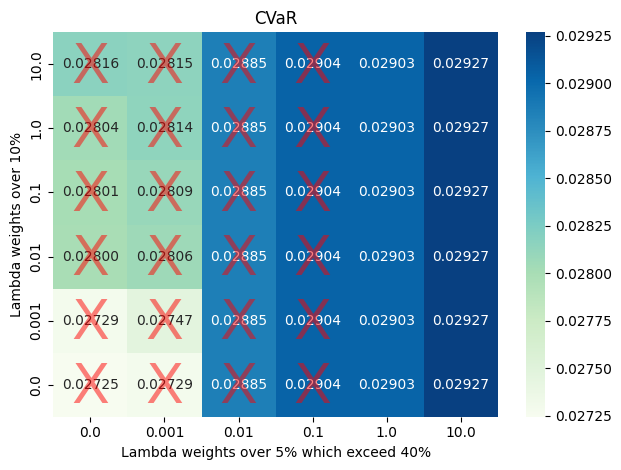

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

heatmap_data = grid_search_df.pivot(index="l_010", columns="l_005040", values="cvar")
heatmap_data = heatmap_data.sort_index(axis=0, ascending=False)
heatmap_data = heatmap_data

# Plot the heatmap with inverted y-axis
fig, ax = plt.subplots()
sns.heatmap(heatmap_data, cmap="GnBu", annot=True, fmt=".5f", ax=ax)

# Draw x where theoretical loss is greater than 0 (do not satisfy UCITS contraints).
for row, col in zip(rows, cols):
    x_coordinate = col + 0.5
    y_coordinate = row + 0.55
    ax.text(x_coordinate, y_coordinate, "X", color="red", ha="center", va="center", fontsize=40, alpha=0.5)

plt.xlabel("Lambda weights over 5% which exceed 40%")
plt.ylabel("Lambda weights over 10%")
plt.title("CVaR")
plt.tight_layout()
plt.savefig("../results/Case_03/MinCVaR_UCITS_gd_optimizer_cvar_loss_heatmap.png", dpi=300)
plt.show()

In [14]:
grid_search_df.to_csv("../results/Case_03/grid_search_results.csv", index=False)